# Experimenting on other ML models
This exercise experiments other Machine Learning model using the same titanic-dataset. This will allow comparison between Linear models like Logistic regression and non-linear complex models like Ensemble techniques.
In this process we will evaluate:
1. Naive Bayes Classifier.
2. K-Nearest Neigbour.
3. Decision Tree Classifiers.
4. Bagging techniques like Random Forest.
5. Boosting technique - Gradient Boosting
5. Boosting technqiue - XGBoost

## Naive Bayes Classifier

### Analyzing the assumptions of the algorithm
Before fitting the model, we will analyse the assumption os the algorithm. This will tell use if our data is meant to be used in Naive Bayes Classifier or not.
Assumptions of Naive Bayes:
1. The output column must be categorical.
2. Conditional independence of independent columns in the dataframe when output Y is given.
3. Normal distribution of numeric columns. If not, use transformations or any other variant of Naive Bayes.
4. Balanced dataset.. If classes are healivy imbalanced, might need priors.

#### Assumption 1 : Output column -> Categorical
This assumption is True for our dataset.

#### Assumption 2 :  Conditional independence of independent columns in the dataframe when output Y is given 
This assumption can be checked by doing pairwise correlation test.

In [48]:
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

numeric_columns = ['Age', 'Fare']
categorical_columns = ['Pclass', 'Sex', 'Embarked', 'Total Family category']
all_columns = ['Age', 'Fare', 'Pclass', 'Sex', 'Embarked', 'Total Family category']

p_values = {
    'col1':[],
    'col2':[],
    'p_value':[],
    'stat_test':[]
}

for i in range(0, len(all_columns)):
    for y in range(i+1, len(all_columns)):
        #column identification
        col1 = all_columns[i]
        col2 = all_columns[y]
        if (col1 in numeric_columns) and (col2 in numeric_columns):
            _, p_value = pearsonr(df[col1], df[col2])
            stat_test = "Pearson"
        elif (col1 in categorical_columns) and (col2 in categorical_columns):
            # Create a contingency table
            contingency_table = pd.crosstab(df[col1], df[col2])
            _, p_value, _, _ = chi2_contingency(contingency_table)
            stat_test = "Chi-Squared"
        else:
            #Checking which one is categorical
            if col1 in categorical_columns:
                groups = [group[col2].values for name, group in df.groupby(col1)]
                _, p_value = f_oneway(*groups)
                stat_test = "Annova"
            else:
                groups = [group[col1].values for name, group in df.groupby(col2)]
                _, p_value = f_oneway(*groups)
                stat_test = "Annova"
        #Appending in the dictionary
        p_values['col1'].append(col1)
        p_values['col2'].append(col2)
        p_values['p_value'].append(p_value)
        p_values['stat_test'].append(stat_test)
        
p_value_df = pd.DataFrame.from_dict(p_values)

Inference : We are able to see the conditinal dependence of the input variables with other input variables. Naive bayes is said to work even if this assumption is not fulfilled. Let's go ahead and check other assumptions.

#### Assumption 3 :  Normal distribution of numeric columns
This will be checked using shapiro-wilk test.

In [49]:
from scipy.stats import shapiro

numeric_columns = ['Age', 'Fare']

for col in numeric_columns:
    _, p_value = shapiro(np.array(df[col]))
    print("Shapiro-Wilk test: ", p_value)

Shapiro-Wilk test:  4.920161676760531e-07
Shapiro-Wilk test:  9.572504387077426e-39


Inference : Data is not normally distributed. **Need to bin the data and use Bernaulli Naive Bayes**.

#### Assumption 4 :  Balanced data
The data is Balanced

#### Feature Engineering after Assumption check
In this step we will change the Age and Fare columns in categotical variables with the help of binning.

In [50]:
#Creating different bins for Age anf Fare columns 
copy_df = df.copy()
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
copy_df['Age_Category'] = pd.cut(copy_df['Age'], bins=age_bins, labels=age_labels, right=False)
copy_df['Fare_Category'] = pd.qcut(copy_df['Fare'], q=4, labels=False, duplicates='drop')
copy_df = copy_df.drop(['Age', 'Fare'], axis = 1)

In [51]:
#One-Hot encoding and Standardization for Categorical and Numerical columns respectively
copy_df = pd.get_dummies(copy_df, columns=["Pclass", "Sex", "Embarked", "Total Family category", "Age_Category", "Fare_Category"], drop_first=True)

### Model development
In this section we will build:
1. Bernaulli Naive Bayes model
2. Multinomial Naive bayes model
2. Categorical Naive Bayes model

#### Bernaulli Naive Bayes

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

#Train test split
X = copy_df.drop("Survived", axis=1)
y = copy_df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Fitting data to the model
bernaulli_naive_bayes = BernoulliNB(alpha=1.0)
bernaulli_naive_bayes.fit(X_train, y_train)

# Make predictions on the test data
y_pred = bernaulli_naive_bayes.predict(X_test)

#Accuracy check
accuracy = accuracy_score(y_test, y_pred)
confusion_matrix = confusion_matrix(y_test, y_pred)
precision = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[1][0])
recall = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[0][1])
print(accuracy)
print(confusion_matrix)
print(precision)
print(recall)

0.7925925925925926
[[68 10]
 [18 39]]
0.7906976744186046
0.8717948717948718


#### Multinomial Naive Bayes

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

#Train test split
X = copy_df.drop("Survived", axis=1)
y = copy_df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Fitting data to the model
multinomial_naive_bayes = MultinomialNB(alpha=1.0) 
multinomial_naive_bayes.fit(X_train, y_train)

# Make predictions on the test data
y_pred = multinomial_naive_bayes.predict(X_test)

#Accuracy check
accuracy = accuracy_score(y_test, y_pred)
confusion_matrix = confusion_matrix(y_test, y_pred)
precision = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[1][0])
recall = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[0][1])
print(accuracy)
print(confusion_matrix)
print(precision)
print(recall)

0.7555555555555555
[[69  9]
 [24 33]]
0.7419354838709677
0.8846153846153846


#### Categorical Naive Bayes

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder

#Creating different bins for Age anf Fare columns 
copy_df = df.copy()
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
copy_df['Age_Category'] = pd.cut(copy_df['Age'], bins=age_bins, labels=age_labels, right=False)
copy_df['Fare_Category'] = pd.qcut(copy_df['Fare'], q=4, labels=False, duplicates='drop')
copy_df = copy_df.drop(['Age', 'Fare'], axis = 1)

#Train test split
X = copy_df.drop("Survived", axis=1)
y = copy_df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize the encoder
encoder = OrdinalEncoder()
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

#Fitting data to the model
categorical_naive_bayes = CategoricalNB(alpha=1.0) 
categorical_naive_bayes.fit(X_train_encoded, y_train)

# Make predictions on the test data
y_pred = categorical_naive_bayes.predict(X_test_encoded)

#Accuracy check
accuracy = accuracy_score(y_test, y_pred)
confusion_matrix = confusion_matrix(y_test, y_pred)
precision = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[1][0])
recall = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[0][1])
print(accuracy)
print(confusion_matrix)
print(precision)
print(recall)

0.8074074074074075
[[68 10]
 [16 41]]
0.8095238095238095
0.8717948717948718


Inference:
- Categorical Naive Bayes gave best results in the terms of overall Accuracy, Precision and Recall. This is primarily beacuse our data is entirelly converted to categories and categorical naive bayes works perfectly on that.

### Model Interpretation: Categorical Naive Bayes
The Categorical Naive Bayes model was selected as the final model due to its strong performance on this dataset. Unlike linear models that produce coefficients, Naive Bayes models make predictions based on the principles of probability. The interpretation, therefore, involves understanding the probabilities the model has learned from the training data.

The core of this model's logic is **Bayes' Theorem**. It calculates the probability of a passenger surviving or not, given their set of features (like class, sex, etc.). This is done by combining two key pieces of information:

1.  **Class Priors `P(Class)`:** The baseline probability of a class (e.g., the overall percentage of survivors in the dataset).
2.  **Conditional Probabilities `P(Feature | Class)`:** The probability of a passenger having a specific feature, given that they belong to a certain class (e.g., the probability a passenger was 'female', given that they survived).

#### 1. Baseline Expectation: The Class Priors

Before considering any passenger-specific details, the model starts with the overall probability of survival from the training data.

<!-- Replace with your actual values -->
*   **Prior Probability of Not Surviving (Class 0):** 57.5%
*   **Prior Probability of Surviving (Class 1):** 42.5%

**Interpretation:** This is our baseline. With no other information, the model assumes any given passenger has a 42.5% chance of survival. The goal of the model is to adjust this probability up or down based on the passenger's features.

#### 2. Key Predictive Factors: Conditional Probabilities

This is the core of the model's "knowledge." For each feature, the model has calculated the probability of observing each category, conditioned on the survival outcome.

To make the interpretation clearer, a **"Lift (Survived)"** metric has been calculated.
*   **Lift = `P(Category | Survived)` / `P(Category | Not Survived)`**
*   **Lift > 1:** This category provides evidence **FOR** survival. The higher the lift, the stronger the evidence.
*   **Lift < 1:** This category provides evidence **AGAINST** survival.

In [55]:
# The model stores log probabilities. We convert them back with np.exp()
class_priors = np.exp(categorical_naive_bayes.class_log_prior_)

print(f"Prior Probability of Not Surviving (Class 0): {class_priors[0]:.2%}")
print(f"Prior Probability of Surviving (Class 1):    {class_priors[1]:.2%}")

Prior Probability of Not Surviving (Class 0): 58.44%
Prior Probability of Surviving (Class 1):    41.56%


In [56]:
# Get the feature names and category labels from the encoder
feature_names = X.columns
category_labels = encoder.categories_

# The model's learned likelihoods are also in log format
feature_log_probs = categorical_naive_bayes.feature_log_prob_

# --- Loop through each feature to print its probabilities ---
for i, feature_name in enumerate(feature_names):
    print(f"\n--- Probabilities for Feature: '{feature_name}' ---")
    
    # Create a DataFrame for easy viewing
    prob_df = pd.DataFrame({
        'Category': category_labels[i],
        'P(Category | Not Survived)': np.exp(feature_log_probs[i][0]), # Class 0
        'P(Category | Survived)': np.exp(feature_log_probs[i][1])    # Class 1
    })
    
    # Calculate the "evidence strength" - how much more likely a category is for survivors
    prob_df['Lift (Survived)'] = prob_df['P(Category | Survived)'] / prob_df['P(Category | Not Survived)']
    
    print(prob_df.round(3))


--- Probabilities for Feature: 'Pclass' ---
   Category  P(Category | Not Survived)  P(Category | Survived)  \
0         1                       0.167                   0.405   
1         2                       0.214                   0.300   
2         3                       0.619                   0.295   

   Lift (Survived)  
0            2.432  
1            1.401  
2            0.476  

--- Probabilities for Feature: 'Sex' ---
  Category  P(Category | Not Survived)  P(Category | Survived)  \
0   female                        0.18                   0.664   
1     male                        0.82                   0.336   

   Lift (Survived)  
0            3.691  
1            0.410  

--- Probabilities for Feature: 'Embarked' ---
  Category  P(Category | Not Survived)  P(Category | Survived)  \
0        C                       0.135                   0.251   
1        Q                       0.057                   0.035   
2        S                       0.808               

## K-Nearest Neigbours
It is a non-paramteric algorithm i.e., it does not require any kind of explicit assumption about the data. But still we need to take care of:
1. "Curse of Dimensionality" in KNN i.e., too much input features can make KNN distance measurement irrelavant.
2. Need to scale the data using Standard Scaling.

### Feature engineering and model training

In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

#Copy_df
copy_df = df.copy()

#Creating dummies
copy_df_encoded = pd.get_dummies(copy_df, columns=["Pclass", "Sex", "Total Family category", "Embarked"], drop_first=True)

# Features and target
X = copy_df_encoded.drop(columns=['Survived'])
y = copy_df_encoded['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled_df, y_train)

# Make predictions on the test data
y_pred = knn.predict(X_test_scaled_df)

#Accuracy check
accuracy = accuracy_score(y_test, y_pred)
confusion_matrix = confusion_matrix(y_test, y_pred)
precision = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[1][0])
recall = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[0][1])
print(accuracy)
print(confusion_matrix)
print(precision)
print(recall)

0.837037037037037
[[73  5]
 [17 40]]
0.8111111111111111
0.9358974358974359


### Interpretting the Model
Interpretting a KNN model is different from interpretting Logistic regression or Naive Bayes. The reason is that, during training process, KNN model fundamentally just stores the data rather than learning parameters as other statistical or linear models does. 

So, let's infere the model by taking 3 different points from the testing data, finding 5 neighours using `sci-kit learn` and infere what model wants to tell.

In [58]:
import random

for i in range(0, 5):
    
    while True:
        random_selection = random.randint(1, len(X_test_scaled))
        if random_selection in X_train.index:
            break
    
    passenger_scaled = X_train_scaled_df.loc[random_selection:random_selection]
    passenger_original = X_train.loc[passenger_scaled.index[0]:passenger_scaled.index[0]]
    
    prediction_on_passenger = knn.predict(passenger_scaled)[0]
    
    distances, neighbor_indices = knn.kneighbors(passenger_scaled)
    neighbor_indices = neighbor_indices[0]
    
    neighbor_df = X_train.iloc[neighbor_indices]
    neighbor_outcomes = y_train.iloc[neighbor_indices]
    
    break

## Decision Tree Classifier
Best thing about the decision trees are that, they do not need a lot of assumptions in the dataset. They can handle the non-normality and non-linearity in the dataset efficiently. Also, using decision trees we can test the accuracy by tuning the data in a lot of ways:
1. We can test model using label encodings for the columns like `Pclass` and `Embarked`. This was not possible in the previous models due to there ability of handling the label encoding datasets.
2. We can test model using one-hot encodings for the same columns.

### Model 1
In this, we will just give the data in whic `Pclass` and `Embarked` will be  in Label encoding and `Sex` and `Total Family category` will be in One-Hot encoding way.

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.tree import plot_tree

#Copy_df
copy_df = df.copy()

#Creating dummies (ONE-HOT-ENCODING)
copy_df_encoded = pd.get_dummies(copy_df, columns=["Sex", "Total Family category"], drop_first=True)

#Creating label encoding
embarked_mapping = {
    'Q': 0,
    "S": 1,
    "C": 2
}
le = LabelEncoder()
copy_df_encoded['Embarked_Encoded'] = copy_df_encoded['Embarked'].map(embarked_mapping)

#Dropping columns
copy_df_encoded = copy_df_encoded.drop('Embarked', axis = 1)

# Features and target
X = copy_df_encoded.drop(columns=['Survived'])
y = copy_df_encoded['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree Classifier model
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = clf.predict(X_test)

#Accuracy check
accuracy = accuracy_score(y_test, y_pred)
confusion_matrix = confusion_matrix(y_test, y_pred)
precision = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[1][0])
recall = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[0][1])
print(accuracy)
print(confusion_matrix)
print(precision)
print(recall)

0.7925925925925926
[[77  1]
 [27 30]]
0.7403846153846154
0.9871794871794872


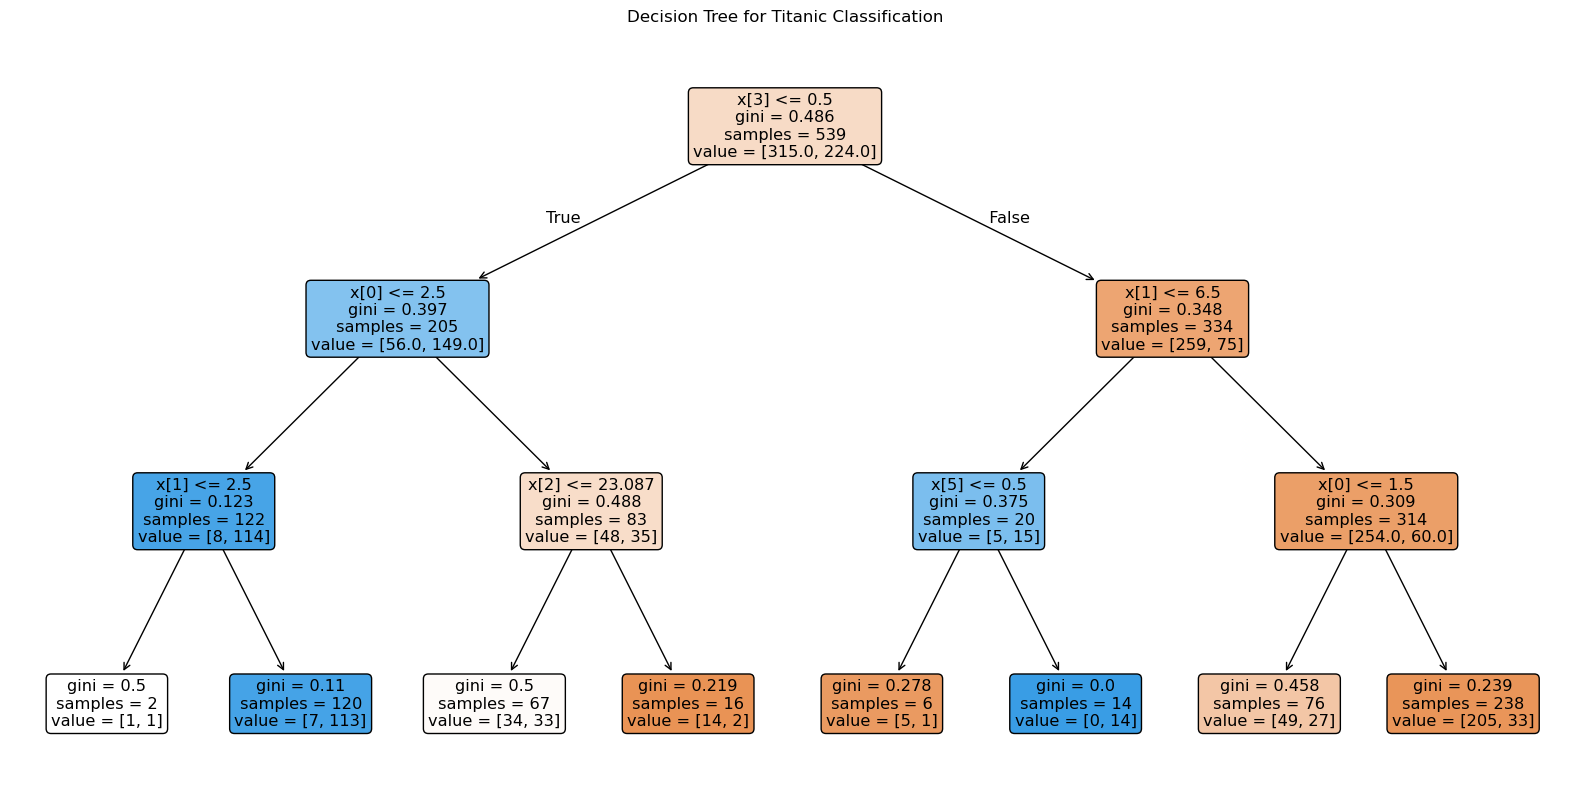

In [60]:
plt.figure(figsize=(20,10))
plot_tree(
    clf,
    filled=True, # Color the nodes to indicate majority class
    rounded=True, # Use rounded corners for the nodes
#     class_names=y.unique(), # Display class names
#     feature_names=X.columns # Display feature names
)
plt.title("Decision Tree for Titanic Classification")
plt.show()

### Model 2
In this, we will just give the data in which all categorial columns (Ordinal, Nominal) will be in One-Hot encoding way.

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.tree import plot_tree

#Copy_df
copy_df = df.copy()

#Creating dummies (ONE-HOT-ENCODING)
copy_df_encoded = pd.get_dummies(copy_df, columns=["Sex", "Total Family category", "Embarked", 'Pclass'], drop_first=True)

# Features and target
X = copy_df_encoded.drop(columns=['Survived'])
y = copy_df_encoded['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree Classifier model
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = clf.predict(X_test)

#Accuracy check
accuracy = accuracy_score(y_test, y_pred)
confusion_matrix = confusion_matrix(y_test, y_pred)
precision = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[1][0])
recall = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[0][1])
print(accuracy)
print(confusion_matrix)
print(precision)
print(recall)

0.7925925925925926
[[77  1]
 [27 30]]
0.7403846153846154
0.9871794871794872


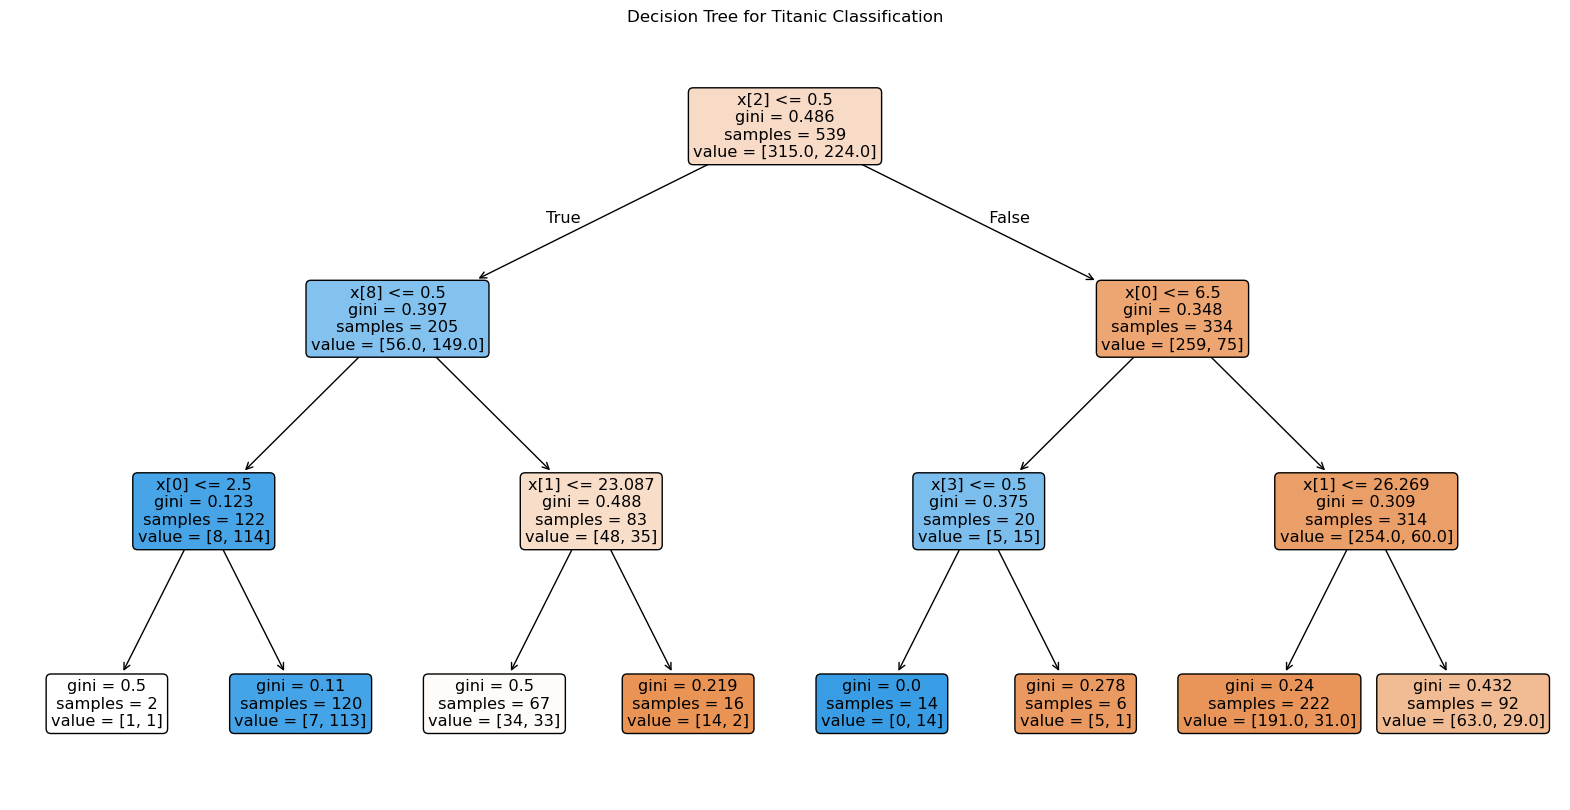

In [62]:
plt.figure(figsize=(20,10))
plot_tree(
    clf,
    filled=True, # Color the nodes to indicate majority class
    rounded=True, # Use rounded corners for the nodes
#     class_names=y.unique(), # Display class names
#     feature_names=X.columns # Display feature names
)
plt.title("Decision Tree for Titanic Classification")
plt.show()

### Hypertuning the Decision Tree Classifiers
Both the models have given same accuracy. Let's pick One-hot encoding one and let's try to hypertune it so that model takes care of Bias-Variance trade off.

Since the dataset is quite small, we will use `GridSearchCV` rather than `RandomSearchCV`

In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.tree import plot_tree

#Copy_df
copy_df = df.copy()

#Creating dummies (ONE-HOT-ENCODING)
copy_df_encoded = pd.get_dummies(copy_df, columns=["Sex", "Total Family category", "Embarked", 'Pclass'], drop_first=True)

# Features and target
X = copy_df_encoded.drop(columns=['Survived'])
y = copy_df_encoded['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], # None means the tree grows until leaves are pure
    'min_samples_split': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'ccp_alpha': [0.0, 0.01, 0.1]
}

clf_base = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=clf_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1 # To see progress
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6600 candidates, totalling 33000 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'ccp_alpha': [0.0, 0.01, 0.1],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_split': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='accuracy', verbose=1)

In [64]:
#Predicting with the Best Decision Tree
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test)

In [65]:
#Accuracy check
accuracy = accuracy_score(y_test, y_pred)
confusion_matrix = confusion_matrix(y_test, y_pred)
precision = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[1][0])
recall = confusion_matrix[0][0]/(confusion_matrix[0][0]+confusion_matrix[0][1])
print(accuracy)
print(confusion_matrix)
print(precision)
print(recall)

0.8
[[73  5]
 [22 35]]
0.7684210526315789
0.9358974358974359


### Inference of the Decision Tree Classifier
Let's infere the model in the form of Decision Tree.

Best Hyperparameters Found:
{'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}

Visualizing the best model...


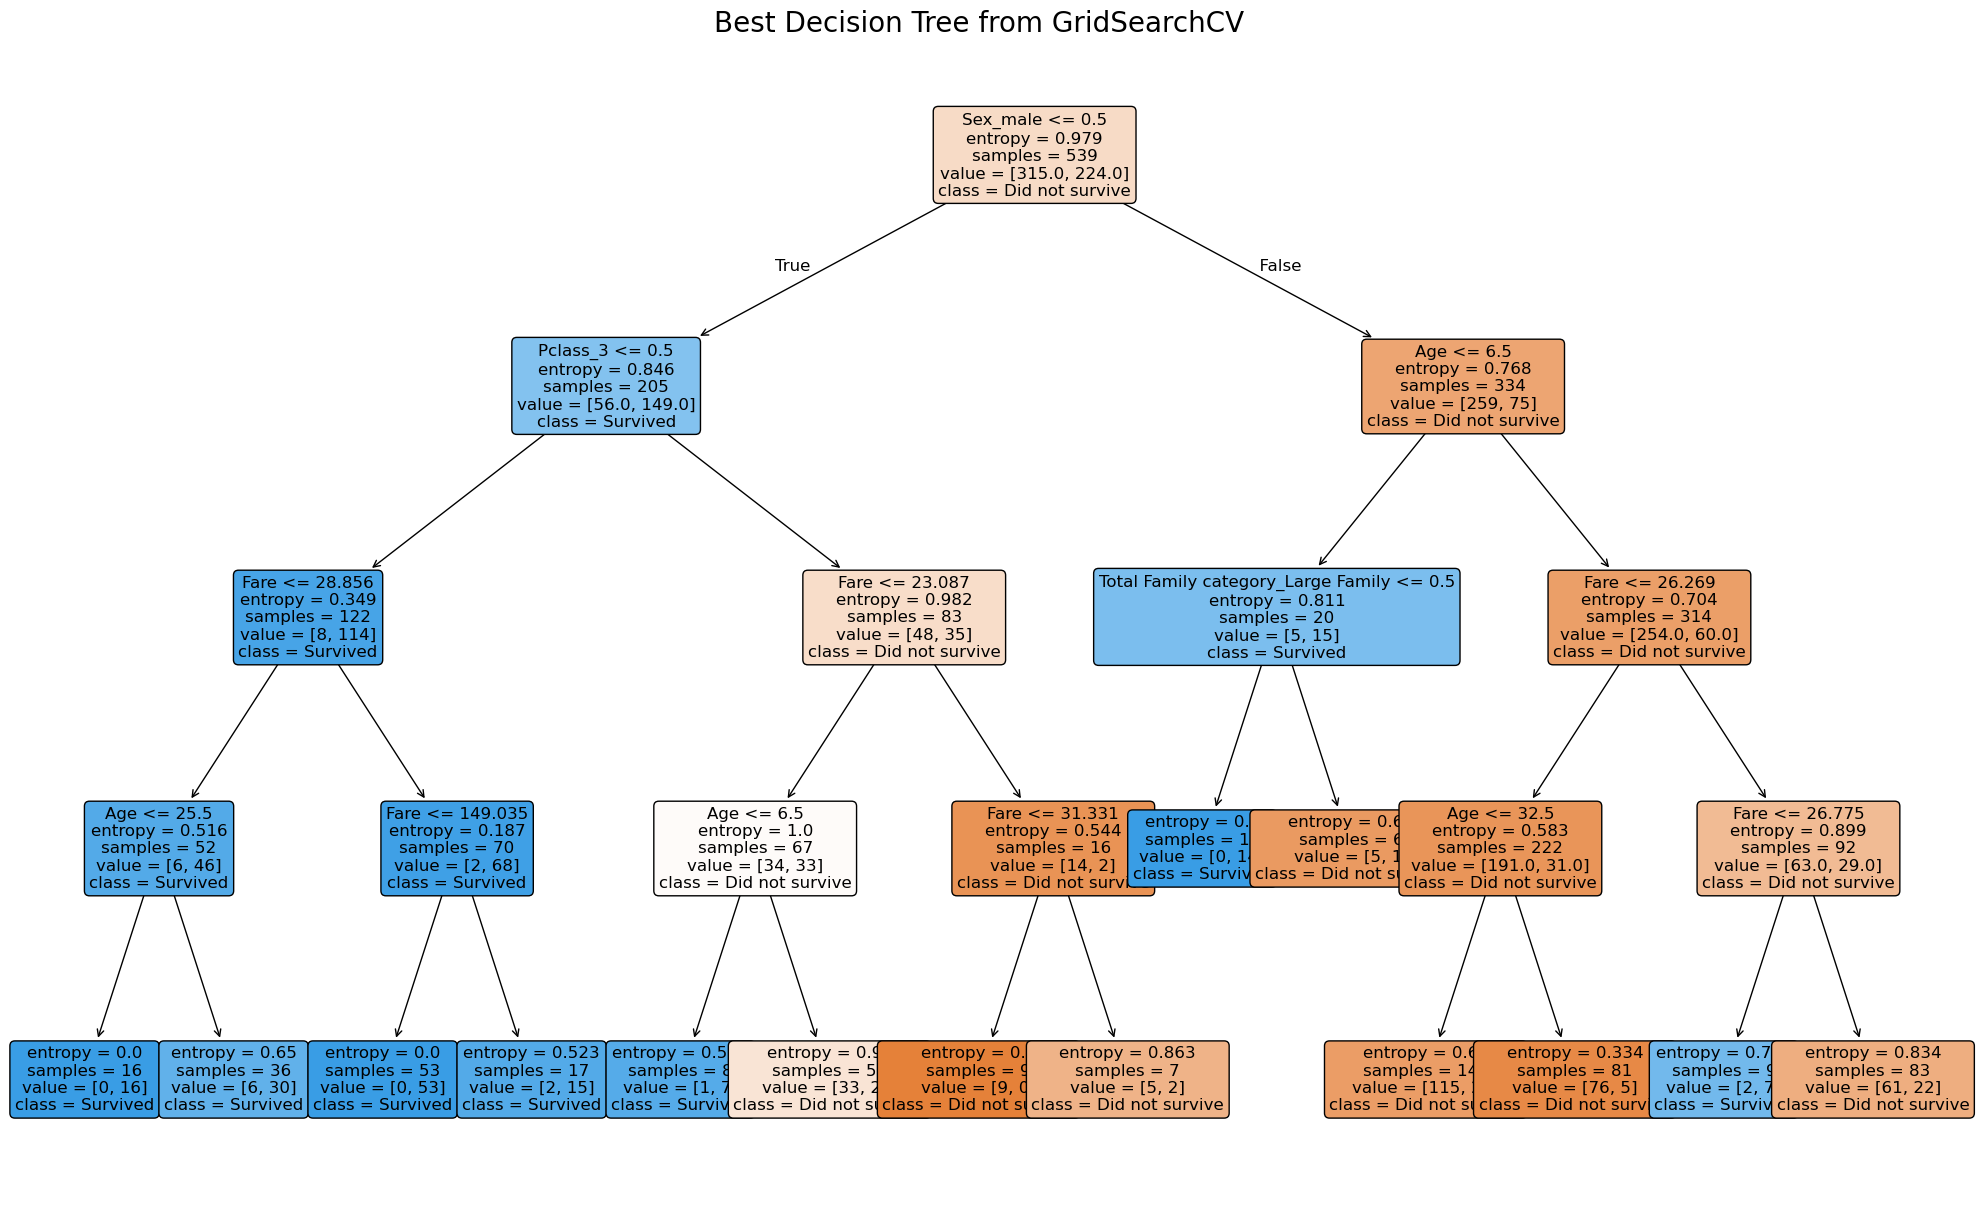

In [67]:
# 1. Access the best model found by GridSearchCV
best_clf = grid_search.best_estimator_

# Let's see which parameters were chosen as the best
print("Best Hyperparameters Found:")
print(grid_search.best_params_)

# 2. Visualize the best decision tree
print("\nVisualizing the best model...")

class_names = ['Did not survive', 'Survived']
feature_names = X.columns.tolist()

plt.figure(figsize=(25, 15)) # Make the figure larger for better readability
plot_tree(
    best_clf,
    filled=True,
    rounded=True,
    class_names=class_names,
    feature_names=feature_names,
    fontsize=12
)
plt.title("Best Decision Tree from GridSearchCV", fontsize=20)
plt.show()

## Ensemble Techique - Bagging - Random Forests

### Model Building

In [69]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#Copy_df
copy_df = df.copy()

#Creating dummies (ONE-HOT-ENCODING)
copy_df_encoded = pd.get_dummies(copy_df, columns=["Sex", "Total Family category", "Embarked", 'Pclass'], drop_first=True)

# Features and target
X = copy_df_encoded.drop(columns=['Survived'])
y = copy_df_encoded['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(
    n_estimators=100, # The number of trees in the forest
    max_depth=10,     # Maximum depth of the tree
    random_state=42,  # For reproducibility
    n_jobs=-1         # Use all available CPU cores
)

# 2. Fit the model to the training data
# This is where the model "learns" from the data.
print("\nTraining the Random Forest model...")
rf_classifier.fit(X_train, y_train)
print("Model training complete!")

# Make predictions on the test data
y_pred = rf_classifier.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on the Test Set: {accuracy * 100:.2f}%")

# Display a more detailed performance report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))


Training the Random Forest model...
Model training complete!

Model Accuracy on the Test Set: 85.19%

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.82      0.95      0.88        78
       Survived       0.91      0.72      0.80        57

       accuracy                           0.85       135
      macro avg       0.87      0.83      0.84       135
   weighted avg       0.86      0.85      0.85       135



### Inference of the rf model

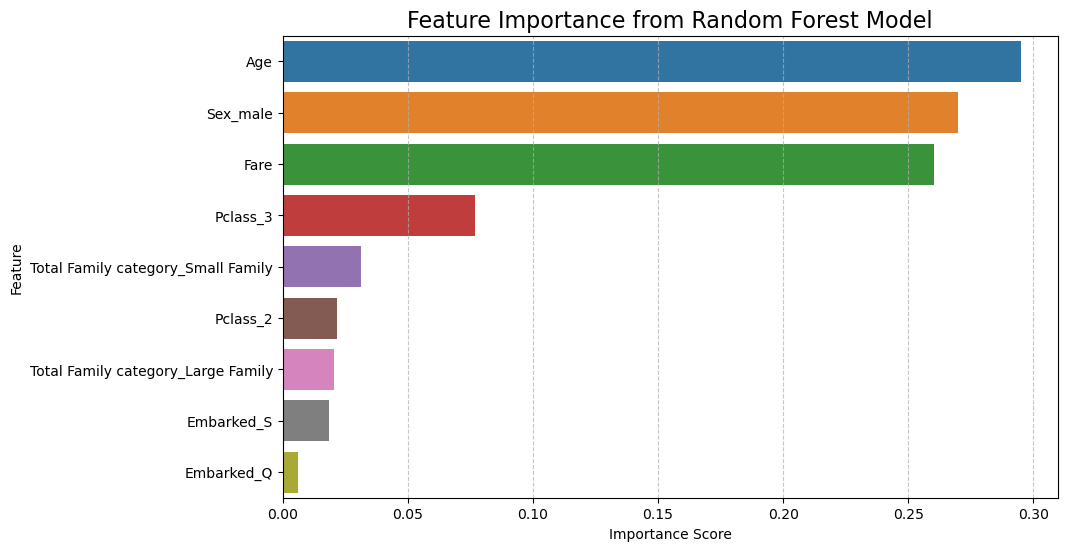


Feature Importances:
                              Feature  Importance
0                                 Age    0.295023
2                            Sex_male    0.269806
1                                Fare    0.260278
8                            Pclass_3    0.076820
4  Total Family category_Small Family    0.031165
7                            Pclass_2    0.021515
3  Total Family category_Large Family    0.020641
6                          Embarked_S    0.018492
5                          Embarked_Q    0.006261


In [70]:
# 1. Extract feature importances from the trained model
importances = rf_classifier.feature_importances_
feature_names = X_train.columns

# 2. Create a pandas DataFrame for easier visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 3. Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Visualize the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest Model', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Print the sorted feature importances
print("\nFeature Importances:")
print(feature_importance_df)

## Ensemble Techique - Boosting - Gradient Boosting

### Model Building

In [74]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

#Copy_df
copy_df = df.copy()

#Creating dummies (ONE-HOT-ENCODING)
copy_df_encoded = pd.get_dummies(copy_df, columns=["Sex", "Total Family category", "Embarked", 'Pclass'], drop_first=True)

# Features and target
X = copy_df_encoded.drop(columns=['Survived'])
y = copy_df_encoded['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb_classifier = GradientBoostingClassifier(
    n_estimators=100,      # Number of boosting stages (trees)
    learning_rate=0.1,     # Shrinks the contribution of each tree
    max_depth=3,           # Limits the complexity of individual trees
    random_state=42
)

# 2. Fit the model to the training data
print("\nTraining the Gradient Boosting model...")
gb_classifier.fit(X_train, y_train)
print("Model training complete!")

# Make predictions on the test data
y_pred = gb_classifier.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on the Test Set: {accuracy * 100:.2f}%")

# Display a more detailed performance report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))


Training the Gradient Boosting model...
Model training complete!

Model Accuracy on the Test Set: 85.93%

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.82      0.96      0.89        78
       Survived       0.93      0.72      0.81        57

       accuracy                           0.86       135
      macro avg       0.88      0.84      0.85       135
   weighted avg       0.87      0.86      0.86       135



### Inferencce of the model

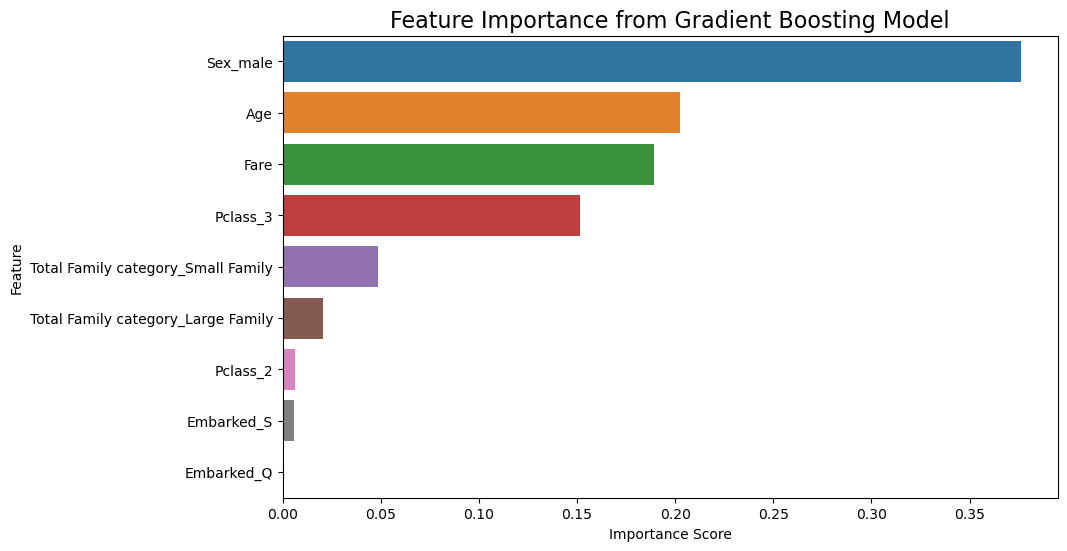

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'gb_classifier' is your trained GradientBoostingClassifier
# and 'X_train' is your training feature DataFrame

# 1. Extract feature importances from the trained model
importances = gb_classifier.feature_importances_
feature_names = X_train.columns

# 2. Create a DataFrame for easier visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Visualize the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Gradient Boosting Model', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## Ensemble Techique - Boosting - XGBoost

### Model building

In [79]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

#Copy_df
copy_df = df.copy()

#Creating dummies (ONE-HOT-ENCODING)
copy_df_encoded = pd.get_dummies(copy_df, columns=["Sex", "Total Family category", "Embarked", 'Pclass'], drop_first=True)

# Features and target
X = copy_df_encoded.drop(columns=['Survived'])
y = copy_df_encoded['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_classifier = xgb.XGBClassifier(
    n_estimators=1000,          # High number of trees, but early stopping will find the best one
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,   # Suppresses a deprecation warning
    eval_metric='logloss',     # Evaluation metric for early stopping
    random_state=42
)

xgb_classifier.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], # Use the test set as the validation set for stopping
    verbose=False                # Set to True to see the training progress
)

# Make predictions on the test data
y_pred = xgb_classifier.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on the Test Set: {accuracy * 100:.2f}%")

# Display a more detailed performance report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))


Model Accuracy on the Test Set: 82.96%

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.83      0.88      0.86        78
       Survived       0.83      0.75      0.79        57

       accuracy                           0.83       135
      macro avg       0.83      0.82      0.82       135
   weighted avg       0.83      0.83      0.83       135



### Inference of the model

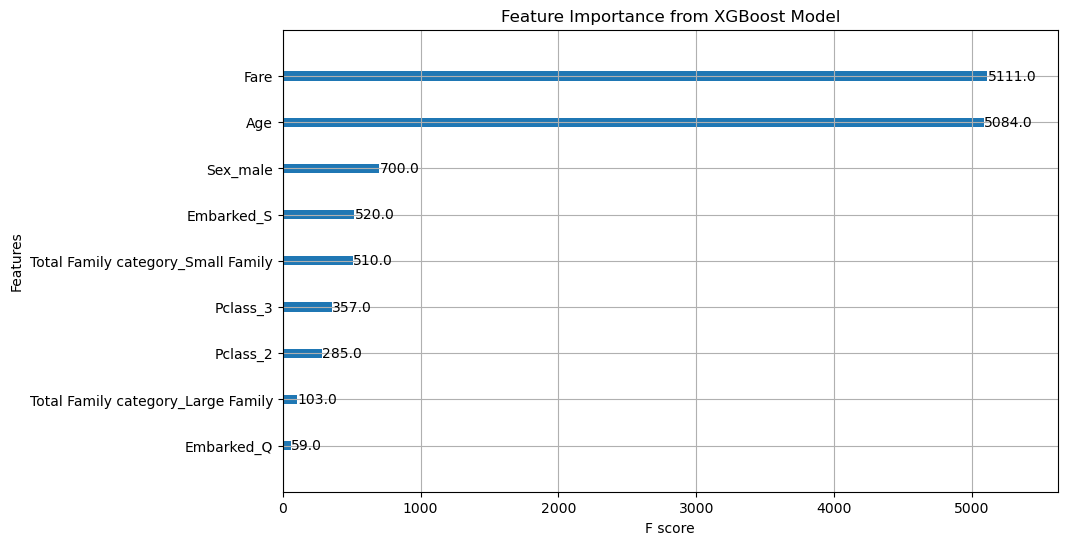

In [80]:
import matplotlib.pyplot as plt

# Use the built-in plot_importance function
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(xgb_classifier, ax=ax)
plt.title("Feature Importance from XGBoost Model")
plt.show()

# Comparing all models

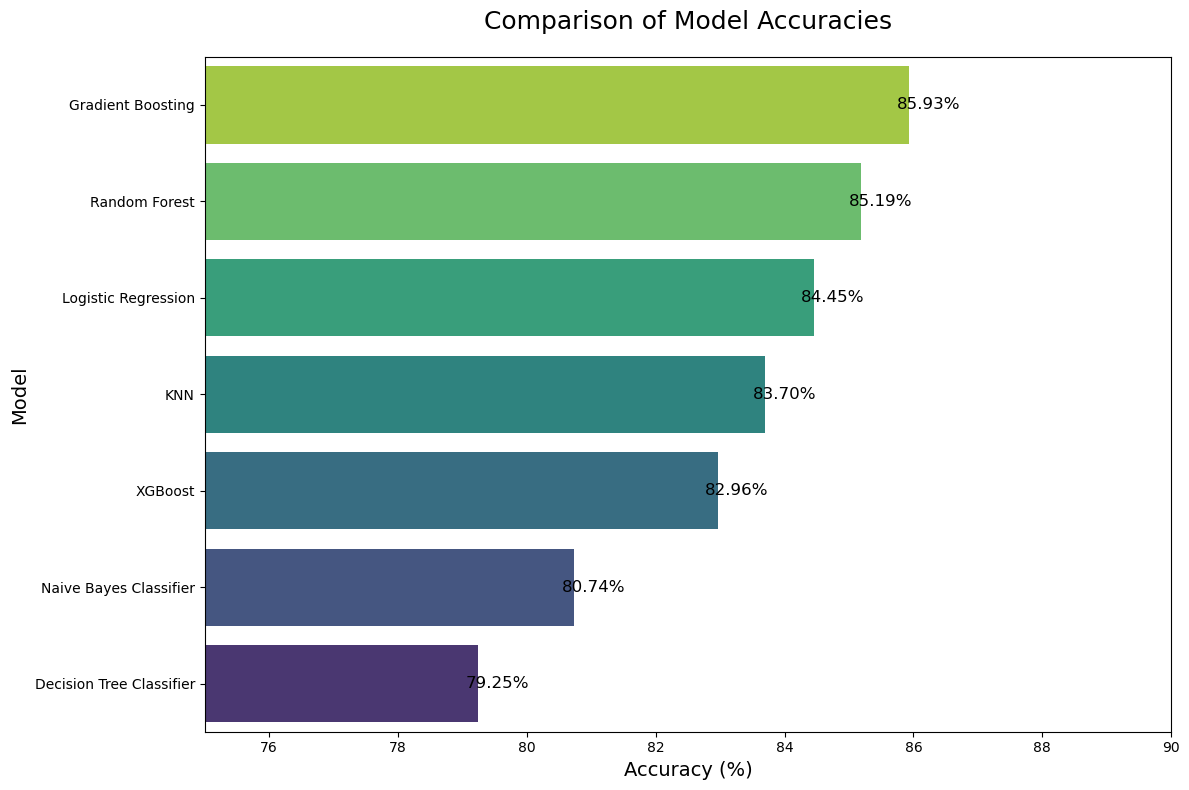

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Your dictionary of model accuracies
model_accuracies = {
    'Logistic Regression' : 84.45,
    'Naive Bayes Classifier' : 80.74,
    'KNN' : 83.70,
    'Decision Tree Classifier' : 79.25,
    "Random Forest" : 85.19,
    "Gradient Boosting" : 85.93,
    "XGBoost" : 82.96
}

# 2. Convert the dictionary to a pandas Series for easier handling and sorting
accuracies_series = pd.Series(model_accuracies)

# 3. Sort the models by accuracy in ascending order
accuracies_sorted = accuracies_series.sort_values(ascending=True)

# 4. Create the horizontal bar plot
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=accuracies_sorted.values, y=accuracies_sorted.index, palette="viridis")

# --- 5. Add Enhancements for a Professional Look ---

# Add a title and labels
plt.title('Comparison of Model Accuracies', fontsize=18, pad=20)
plt.xlabel('Accuracy (%)', fontsize=14)
plt.ylabel('Model', fontsize=14)

# Set the x-axis limit to make the differences more apparent
plt.xlim(75, 90)

# Add the accuracy values as text on each bar
for i in ax.patches:
    # get_width pulls the length of the bar
    width = i.get_width()
    # get_y pulls the position of the bar on the y-axis
    y = i.get_y()
    # get_height is the thickness of the bar
    height = i.get_height()
    # Add text to the bar
    ax.text(width + 0.3,           # x-position of text (slightly past the bar)
            y + height / 2,        # y-position of text (centered on the bar)
            f'{width:.2f}%',       # The text to display (formatted to 2 decimal places)
            ha='center',           # Horizontal alignment
            va='center',           # Vertical alignment
            fontsize=12)

# Invert the y-axis to have the best model on top (optional but recommended)
ax.invert_yaxis()

plt.tight_layout()
plt.show()



### What the Visualization Shows

The resulting chart provides an immediate, clear comparison of your models:
*   **Best Performer:** You can instantly see that **Gradient Boosting** is the top-performing model with an accuracy of 85.93%.
*   **Ranking:** The models are clearly ranked from best to worst, making it easy to see the performance hierarchy.
*   **Performance Tiers:** You can identify groups of similarly performing models, such as Gradient Boosting and Random Forest being very close at the top, followed by a second tier including Logistic Regression and KNN.
*   **Clear Justification:** This visual provides strong evidence to justify your choice of the best model for your specific problem.
